In [1]:
%cd nanoVLM
import os
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

import models.config as config
from models.vision_language_model_action import VisionLanguageActionModel
from minigrid.envs.empty import EmptyEnv
from data.processors import get_image_processor, get_image_string
from data.emptyenv_action_dataset import DEFAULT_PROMPT

ID2ACTION = {0: "left", 1: "right", 2: "forward"}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# общий конфиг (одинаковый для всех прогонов)
vlm_cfg = config.VLMConfig()
vlm_cfg.max_img_size = 512

# общий image_processor (одинаковый для всех прогонов)
image_processor = get_image_processor(
    vlm_cfg.max_img_size,
    vlm_cfg.vit_img_size,
    vlm_cfg.resize_to_max_side_len
)

@torch.no_grad()
def policy_action_from_rgb(model, rgb, prompt=DEFAULT_PROMPT, temperature=1.0, greedy=False):
    """
    temperature > 1.0  -> more exploration
    temperature < 1.0  -> more greedy
    greedy=True        -> argmax regardless of temperature
    """
    tokenizer = model.tokenizer
    device = next(model.parameters()).device

    img = Image.fromarray(rgb).convert("RGB")
    processed_image, splitted_image_count = image_processor(img)

    messages = [{"role": "user", "content": prompt}]
    image_string = get_image_string(tokenizer, [splitted_image_count], vlm_cfg.mp_image_token_length)
    messages[0]["content"] = image_string + messages[0]["content"]

    conv = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_special_tokens=False,
        return_dict=True,
    )

    input_ids = torch.tensor(conv["input_ids"], dtype=torch.long).unsqueeze(0).to(device)
    attention_mask = torch.tensor(conv["attention_mask"], dtype=torch.long).unsqueeze(0).to(device)
    images = [[processed_image]]  # batch size 1

    logits, _ = model(
        input_ids=input_ids,
        images=images,
        attention_mask=attention_mask,
        action_labels=None
    )  # logits: [1, 3]
    logits = logits[0]  # [3]

    if greedy:
        probs = torch.softmax(logits, dim=-1)
        action = int(torch.argmax(probs).item())
        return action, probs.detach().cpu().numpy()

    T = float(temperature)
    if T <= 0:
        raise ValueError("temperature must be > 0")

    probs = torch.softmax(logits / T, dim=-1)
    action = int(torch.multinomial(probs, num_samples=1).item())
    return action, probs.detach().cpu().numpy()


def run_eval(model, num_episodes=20, sizes=[6, 7], max_steps=200, seed=0,
             temperature=1.0, greedy=False, render=False):
    successes = 0
    returns = []
    lengths = []

    rng = np.random.default_rng(seed)

    for ep in range(num_episodes):
        size = int(rng.choice(sizes))
        env = EmptyEnv(size=size, agent_start_pos=None, render_mode="rgb_array")
        obs, info = env.reset(seed=seed + ep)

        env.agent_dir = int(rng.integers(0, 4))

        ep_ret = 0.0
        ep_len = 0
        terminated = False
        truncated = False

        while not (terminated or truncated):
            rgb = env.render()

            action, probs = policy_action_from_rgb(
                model,
                rgb,
                temperature=temperature,
                greedy=greedy
            )

            obs, reward, terminated, truncated, info = env.step(action)
            ep_ret += float(reward)
            ep_len += 1

            if render:
                print(f"ep={ep} t={ep_len} a={ID2ACTION[action]} probs={np.round(probs,3)}")

            if ep_len >= max_steps:
                break

        success = 1 if ep_ret > 0 else 0
        successes += success
        returns.append(ep_ret)
        lengths.append(ep_len)

        print(f"[EP {ep}] size={size} success={success} return={ep_ret:.2f} len={ep_len}")

        env.close()

    metrics = {
        "success_rate": successes / num_episodes,
        "avg_return": float(np.mean(returns)),
        "avg_length": float(np.mean(lengths)),
    }
    return metrics


def load_model_for_step(step, base_ckpt_dir):
    """
    step=None -> необученная модель
    иначе грузим чекпоинт step_{step}
    """
    if step is None:
        model = VisionLanguageActionModel(vlm_cfg, load_backbone=True, num_actions=3)
    else:
        ckpt_path = os.path.join(base_ckpt_dir, f"step_{step}")
        model = VisionLanguageActionModel.from_pretrained(ckpt_path)

    model.to(device)
    model.eval()
    return model


# ==== основной прогон ====

base_ckpt_dir = "/teamspace/studios/this_studio/nanoVLM-action/nanoVLM/checkpoints_emptyenv_action/base_sft"

steps = [None, 125, 250, 375]   # None = необученная
results = {}

common_eval_kwargs = dict(
    num_episodes=80,
    sizes=[8, 9],
    max_steps=100,
    seed=123,
    temperature=1.8,
    greedy=False,
    render=False
)

for step in steps:
    model = load_model_for_step(step, base_ckpt_dir)
    metrics = run_eval(model, **common_eval_kwargs)

    key = 0 if step is None else step
    results[key] = metrics

    print(f"\n=== step={key} ===")
    print(f"Success rate: {metrics['success_rate']:.3f}")
    print(f"Avg return:   {metrics['avg_return']:.3f}")
    print(f"Avg length:   {metrics['avg_length']:.1f}")

    # если VRAM впритык, можно подчистить между моделями
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/teamspace/studios/this_studio/nanoVLM-action/nanoVLM


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Resize to max side len: True
Loading from backbone weights


Successfully loaded google/siglip2-base-patch16-512 weights from safetensors. Model has 86,433,024 parameters.
Extending token embeddings from torch.Size([49152, 960]) to torch.Size([49218, 960])
Initialized 66 new token embeddings
Successfully loaded HuggingFaceTB/SmolLM2-360M-Instruct weights from safetensors. Model has 361,884,480 parameters.
[EP 0] size=8 success=0 return=0.00 len=100
[EP 1] size=9 success=0 return=0.00 len=100
[EP 2] size=9 success=0 return=0.00 len=100
[EP 3] size=8 success=1 return=0.96 len=11
[EP 4] size=8 success=0 return=0.00 len=100
[EP 5] size=8 success=0 return=0.00 len=100
[EP 6] size=8 success=0 return=0.00 len=100
[EP 7] size=8 success=0 return=0.00 len=100
[EP 8] size=9 success=1 return=0.97 len=12
[EP 9] size=9 success=0 return=0.00 len=100
[EP 10] size=8 success=0 return=0.00 len=100
[EP 11] size=8 success=0 return=0.00 len=100
[EP 12] size=8 success=0 return=0.00 len=100
[EP 13] size=9 success=0 return=0.00 len=100
[EP 14] size=8 success=0 return=0.

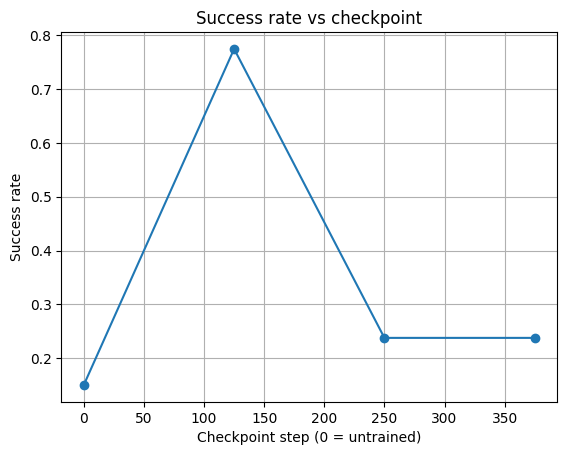

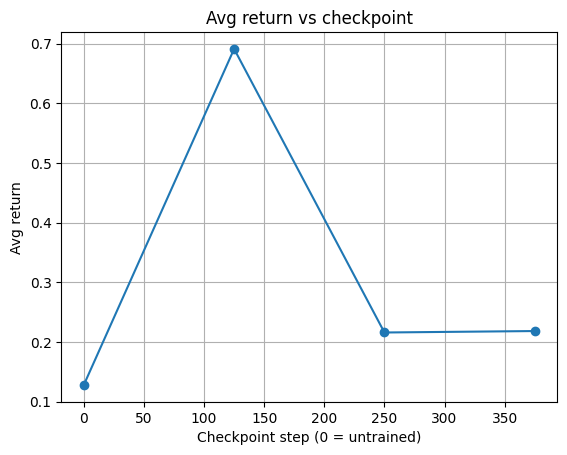

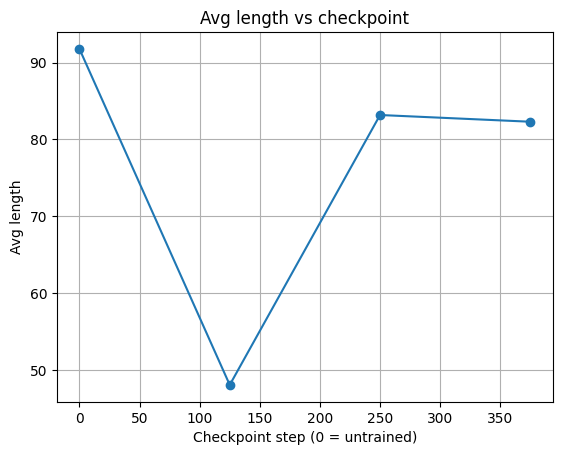

In [2]:
# ==== графики ==== температура 1.8 sft_base 20k sizes 6 7, unseen 8 9, 80 eps

xs = sorted(results.keys())
succ = [results[x]["success_rate"] for x in xs]
ret  = [results[x]["avg_return"] for x in xs]
leng = [results[x]["avg_length"] for x in xs]

plt.figure()
plt.plot(xs, succ, marker="o")
plt.xlabel("Checkpoint step (0 = untrained)")
plt.ylabel("Success rate")
plt.title("Success rate vs checkpoint")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(xs, ret, marker="o")
plt.xlabel("Checkpoint step (0 = untrained)")
plt.ylabel("Avg return")
plt.title("Avg return vs checkpoint")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(xs, leng, marker="o")
plt.xlabel("Checkpoint step (0 = untrained)")
plt.ylabel("Avg length")
plt.title("Avg length vs checkpoint")
plt.grid(True)
plt.show()

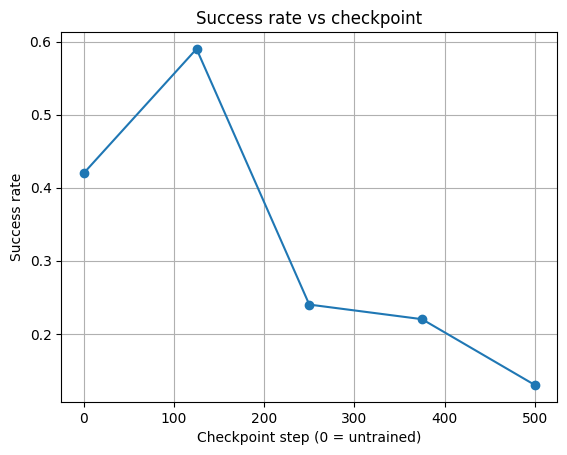

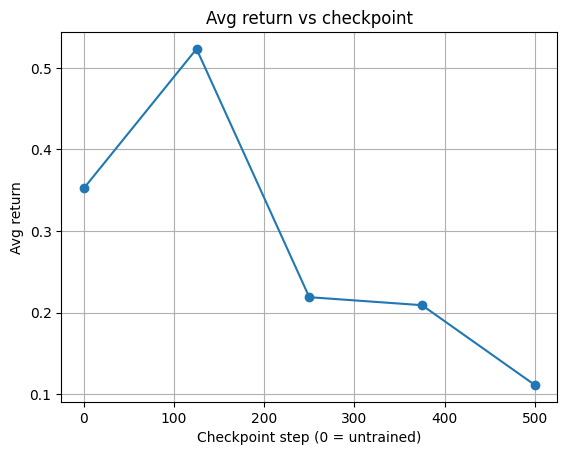

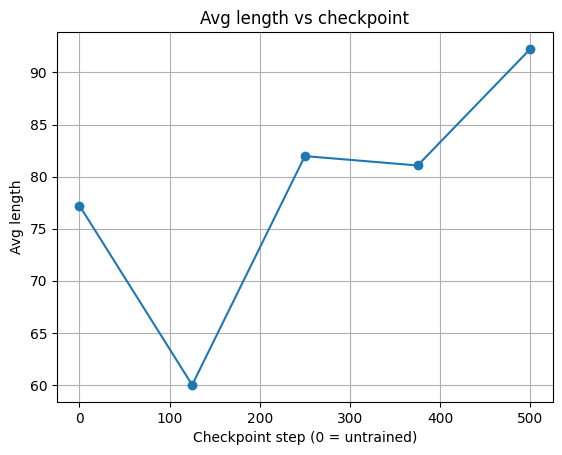

In [5]:
# ==== графики ==== температура 1.8 base 8k sizes 6,7

xs = sorted(results.keys())
succ = [results[x]["success_rate"] for x in xs]
ret  = [results[x]["avg_return"] for x in xs]
leng = [results[x]["avg_length"] for x in xs]

plt.figure()
plt.plot(xs, succ, marker="o")
plt.xlabel("Checkpoint step (0 = untrained)")
plt.ylabel("Success rate")
plt.title("Success rate vs checkpoint")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(xs, ret, marker="o")
plt.xlabel("Checkpoint step (0 = untrained)")
plt.ylabel("Avg return")
plt.title("Avg return vs checkpoint")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(xs, leng, marker="o")
plt.xlabel("Checkpoint step (0 = untrained)")
plt.ylabel("Avg length")
plt.title("Avg length vs checkpoint")
plt.grid(True)
plt.show()